## Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, Callback

## Load Dataset

In [2]:
df = pd.read_csv("dataset_sigaleh_Final.csv")

df.head()

,Komoditas (Rp),Tanggal,Harga,Wilayah,Bulan,Tahun,Hari_Dalam_Minggu,Musim_Hujan,Suhu_Rata2_C,Curah_Hujan_mm,Radiasi_Matahari_MJm2,Kecepatan_Angin_Max_kmh,Hujan_Lag30,Hujan_Lag60,Suhu_Lag30,Suhu_Lag60,Rata_Hujan_30Hari,Rata_Suhu_30Hari,Harga_Kemarin,Harga_Minggu_Lalu
0,Bawang Merah,2020-03-26,31000.0,Bukittinggi,3,2020,3,1,21.1,20.1,16.55,10.9,26.6,0.7,21.2,20.7,8.666667,21.186667,31000.0,31000.0
1,Bawang Merah,2020-03-27,33500.0,Bukittinggi,3,2020,4,1,21.3,5.6,19.03,9.7,23.9,4.0,21.0,20.8,8.056667,21.196667,31000.0,31000.0
2,Bawang Merah,2020-03-30,33500.0,Bukittinggi,3,2020,0,1,21.8,21.6,18.10,12.0,12.8,1.1,20.9,20.9,8.350000,21.226667,33500.0,32750.0
3,Bawang Merah,2020-03-31,36000.0,Bukittinggi,3,2020,1,1,21.2,2.0,16.47,6.5,10.5,7.6,20.7,20.8,8.066667,21.243333,33500.0,32250.0
4,Bawang Merah,2020-04-01,36000.0,Bukittinggi,4,2020,2,0,21.0,13.2,16.34,8.2,7.7,1.0,19.6,20.9,8.250000,21.290000,36000.0,31000.0


## Filter Data

In [3]:
df = df[
    (df['Komoditas (Rp)'] == 'Bawang Merah') &
    (df['Wilayah'] == 'Bukittinggi')
]

## Sort Time Series

In [4]:
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

df = df.sort_values(by='Tanggal')
df = df.reset_index(drop=True)

## Handle Missing Value

In [5]:
df = df.fillna(method='ffill')

/tmp/ipykernel_33902/569672361.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


## Fitur

In [6]:
features = df[[
    'Harga',
    'Suhu_Rata2_C',
    'Curah_Hujan_mm',
    'Harga_Kemarin',
    'Harga_Minggu_Lalu'
]]

## Split


In [7]:
train_size = int(len(features) * 0.8)

train_data = features[:train_size]
test_data = features[train_size:]

## Sclaing

In [8]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

In [9]:
scaled_data = np.concatenate([train_scaled, test_scaled])

## Sliding Window

In [10]:
window_size = 30

X = []
y = []

for i in range(window_size, len(scaled_data)):

    X.append(scaled_data[i-window_size:i])

    y.append(scaled_data[i, 0])  # Harga

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

(1545, 30, 5) (1545,)


## Split Time Series

In [11]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

## Model LSTM

In [12]:
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

x = LSTM(64, return_sequences=True)(input_layer)
x = LSTM(32)(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)

output = Dense(1)(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,425 (122.75 KB)

 Trainable params: 31,425 (122.75 KB)

 Non-trainable params: 0 (0.00 B)

## Custom Callback

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"Epoch {epoch+1} selesai | Loss: {logs['loss']:.4f}")

## Training Model

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop, CustomCallback()]
)

Epoch 1/50
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0550 - mae: 0.1599Epoch 1 selesai | Loss: 0.0225
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0225 - mae: 0.0983 - val_loss: 0.0110 - val_mae: 0.0753
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0083 - mae: 0.0646Epoch 2 selesai | Loss: 0.0062
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0062 - mae: 0.0553 - val_loss: 0.0133 - val_mae: 0.0855
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0039 - mae: 0.0464Epoch 3 selesai | Loss: 0.0037
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0037 - mae: 0.0449 - val_loss: 0.0067 - val_mae: 0.0594
Epoch 4/50
60/62 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0043 - mae: 0.0451Epoch 4 selesai | Loss: 0.0036
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0036 - mae: 0.0432 - val_loss: 0.0087 - val_mae: 0.0676
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0034 - mae: 0.0411Epoch 5 selesai | Loss: 0.0030
62/62 ━━━━━━━━━━━━━━━━━━━━

## Prediksi

In [15]:
pred = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


## Inverse Scaling

In [16]:
harga_min = scaler.data_min_[0]
harga_max = scaler.data_max_[0]

pred_inv = pred * (harga_max - harga_min) + harga_min

y_test_inv = y_test.reshape(-1,1) * (harga_max - harga_min) + harga_min

## Evaluasi

In [17]:
rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))

mape = np.mean(
    np.abs((y_test_inv - pred_inv) / y_test_inv)
) * 100

print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

RMSE : 1941.22
MAPE : 3.52%


## Visualisasi

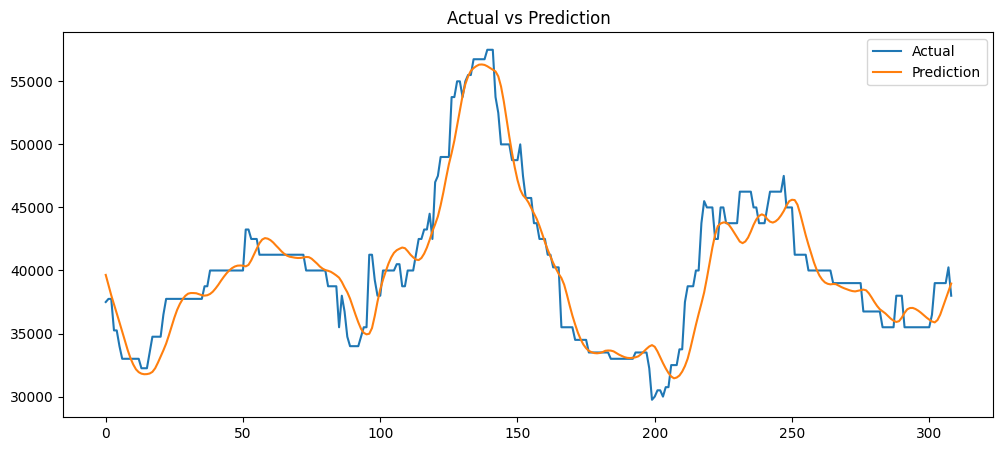

In [18]:
plt.figure(figsize=(12,5))

plt.plot(y_test_inv, label='Actual')
plt.plot(pred_inv, label='Prediction')

plt.title('Actual vs Prediction')
plt.legend()

plt.show()

## Save Model

In [19]:
model.save("model_lstm.keras")

import joblib
joblib.dump(scaler, "scaler.save")

['scaler.save']